In [30]:
import numpy as np
import rasterio
import os
import torch

import matplotlib.pyplot as plt
import torchgeo.models

In [8]:

img_by_site_dir = '../data/int/sentinel_by_site'

In [107]:
train_sites_within_S2_tile = [
    ['KaringaniVultureSite01'],
    ['KaringaniSite11DevNodeF'],
    ['KaringaniSouthSouthDevNode'],
    ['KaringaniSite15'],
    ['KaringaniSite06'],
    ['KaringaniSite12'],
    ['KaringaniSite16'],
    ['KaringaniSite13'],
]

In [194]:
rcf = torchgeo.models.RCF(features = 64, in_channels=3, kernel_size=5)

In [195]:
X_by_site_id = []
for site_id in train_sites_within_S2_tile:
   # print(site_id)
    site_id = site_id[0]
    vis_tifs = [x for x in os.listdir(os.path.join(img_by_site_dir, site_id)) if 'TCI' in x]
    with rasterio.open(os.path.join(img_by_site_dir, site_id, vis_tifs[0])) as f:
        data = f.read()
    
    
    X = rcf(torch.Tensor(data))
    X_by_site_id.append(X.numpy())
X_by_site_id = np.array(X_by_site_id)

In [196]:
rs = np.random.RandomState(0)
data.shape

(3, 532, 521)

In [203]:
n_per_image = 200
subimage_size = [3,21,21]
rs = np.random.RandomState(0)

X_by_site_id_sampled = []
sites_sampled = []

for s,site_id in enumerate(train_sites_within_S2_tile):
   # print(site_id)
    site_id = site_id[0]
    vis_tifs = [x for x in os.listdir(os.path.join(img_by_site_dir, site_id)) if 'TCI' in x]
    with rasterio.open(os.path.join(img_by_site_dir, site_id, vis_tifs[0])) as f:
        data = f.read()
    
        for i in range(n_per_image):
            x0 = rs.randint(0,data.shape[1]-subimage_size[1])
            y0 = rs.randint(0,data.shape[2]-subimage_size[2])
            x1 = x0 + subimage_size[1]
            y1 = y0 + subimage_size[2]

            X = rcf(torch.Tensor(data[:,x0:x1, y0:y1])/ 255.) 
            X_by_site_id_sampled.append(X.numpy())
            sites_sampled.append(s)
        
X_by_site_id_sampled = np.array(X_by_site_id_sampled)

In [204]:
import seaborn as sns

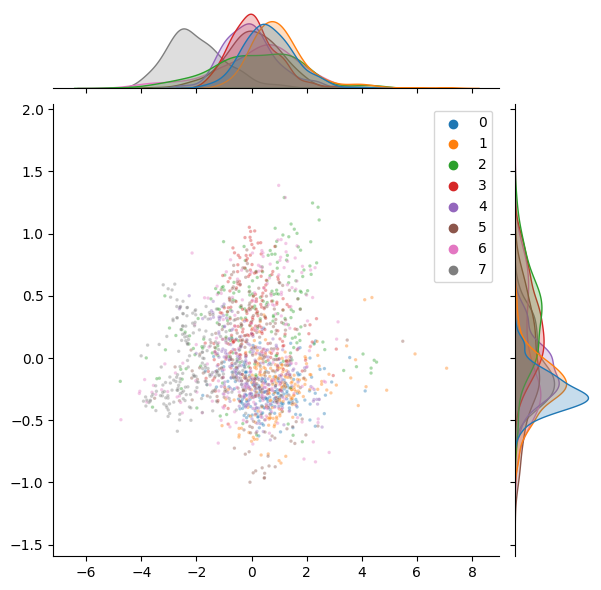

In [205]:
X_sampled_pca = pca.fit_transform(X_by_site_id_sampled)
#plt.bar(np.arange(len(pca.explained_variance_ratio_)), pca.explained_variance_ratio_)
sns.jointplot(x=X_sampled_pca[:,0], y=X_sampled_pca[:,1], hue=sites_sampled, palette='tab10', alpha=0.4, s=6)
#plt.colorbar()


In [ ]:
# which three cover the space best

In [186]:
for s,site in enumerate(train_sites_within_S2_tile):
    print(s,site[0])
    

0 KaringaniVultureSite01
1 KaringaniSite11DevNodeF
2 KaringaniSouthSouthDevNode
3 KaringaniSite15
4 KaringaniSite06
5 KaringaniSite12
6 KaringaniSite16
7 KaringaniSite13


In [171]:
import sklearn.decomposition
pca = sklearn.decomposition.PCA()

In [177]:
#import seaborn as sns
#cmap = sns.color_palette(7)


In [135]:
X_pca = pca.fit_transform(X_by_site_id)

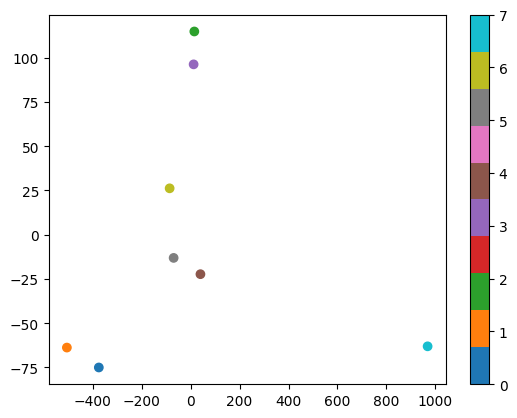

In [136]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=np.arange(len(X_pca)), cmap='tab10')
plt.colorbar()

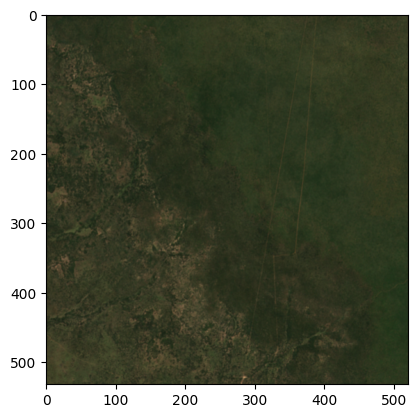

In [122]:
plt.imshow(data.transpose(1,2,0) / 255.)